## Importing Filters

Determines range of wavelengths from each filter

In [14]:
import matplotlib as mpl
import os

os.environ["PATH"] += r";D:\code\miktex\bin\x64"

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

In [15]:
import os
import numpy as np

filter_folder = r"D:\Users\nina\Star_Formation_Histories\Filters"

global_min = np.inf
global_max = -np.inf

for fname in os.listdir(filter_folder):
    if fname.endswith(".txt"):

        filepath = os.path.join(filter_folder, fname)
        data = np.loadtxt(filepath)

        lam_min = data[:, 0].min()
        lam_max = data[:, 0].max()

        global_min = min(global_min, lam_min)
        global_max = max(global_max, lam_max)

        print(f"{fname:20s}  {lam_min:.0f} – {lam_max:.0f} Å")

print("\nOverall wavelength coverage:")
print(f"{global_min:.0f} – {global_max:.0f} Å")

HST_ACS_WFC_F435W.txt  3526 – 4979 Å
HST_ACS_WFC_F606W.txt  4569 – 7283 Å
HST_ACS_WFC_F814W.txt  6738 – 9778 Å
HST_WFC3_IR_F105W.txt  8650 – 12250 Å
HST_WFC3_IR_F125W.txt  10640 – 14390 Å
HST_WFC3_IR_F140W.txt  11370 – 16450 Å
HST_WFC3_IR_F160W.txt  13664 – 17205 Å
JWST_NIRCam_F090W.txt  7836 – 10356 Å
JWST_NIRCam_F115W.txt  9892 – 13282 Å
JWST_NIRCam_F150W.txt  12798 – 17238 Å
JWST_NIRCam_F200W.txt  16904 – 22984 Å
JWST_NIRCam_F277W.txt  23371 – 33015 Å
JWST_NIRCam_F356W.txt  29930 – 42294 Å
JWST_NIRCam_F410M.txt  36740 – 45226 Å
JWST_NIRCam_F444W.txt  37132 – 50996 Å

Overall wavelength coverage:
3526 – 50996 Å


Importing the relevant filters

In [16]:
import os
import numpy as np

filter_folder = r"D:\Users\nina\Star_Formation_Histories\Filters"

filter_files = [
    os.path.join(filter_folder, f)
    for f in os.listdir(filter_folder)
    if f.endswith(".txt")
]

filter_files.sort()

print(filter_files)

['D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_ACS_WFC_F435W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_ACS_WFC_F606W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_ACS_WFC_F814W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_WFC3_IR_F105W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_WFC3_IR_F125W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_WFC3_IR_F140W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_WFC3_IR_F160W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F090W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F115W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F150W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F200W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F277W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F356W.txt'

## Setting age ranges

In [17]:

import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

ages_myr_1 = np.arange(0,110,10)
ages_myr_2 = np.arange(200, 1100, 100)

years = np.concatenate([ages_myr_1, ages_myr_2]) / 1000

## Defining Dust and Nebula

In [18]:

dust = {}
dust["type"] = "Calzetti"
dust["Av"] = 0.2
dust["eta"] = 2. #multiplies Av - extra dust for young stars

nebular = {}   #nebular emission component
nebular["logU"] = -3.   #log_10(ionization parameter)

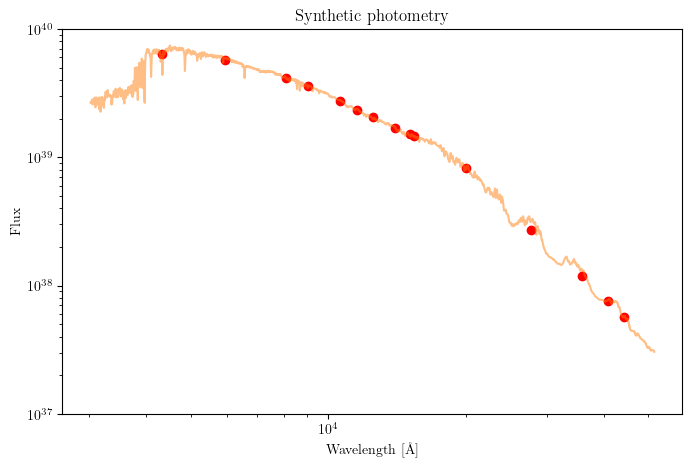

In [19]:

for t in years:

    burst = {
        "age": t,
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }
    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
       spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

    )

    # synthetic photometry
    photometry = model.photometry  # shape = (num_filters, )

    filter_wavelengths = []

for ffile in filter_files:
    filt_data = np.loadtxt(ffile)
    wave = filt_data[:,0]
    transmission = filt_data[:,1]
    eff_wave = np.sum(wave * transmission) / np.sum(transmission)
    filter_wavelengths.append(eff_wave)

filter_wavelengths = np.array(filter_wavelengths)
photometry = np.array(model.photometry)  # flux in each filter

plt.figure(figsize=(8,5))
plt.scatter(filter_wavelengths, photometry, color='red')
plt.plot(model.spec_wavs, model.spectrum, alpha=0.5)  # overlay SED
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux")
plt.title("Synthetic photometry")
plt.ylim(1e37,1e40)
plt.show()

    

### visualising filters

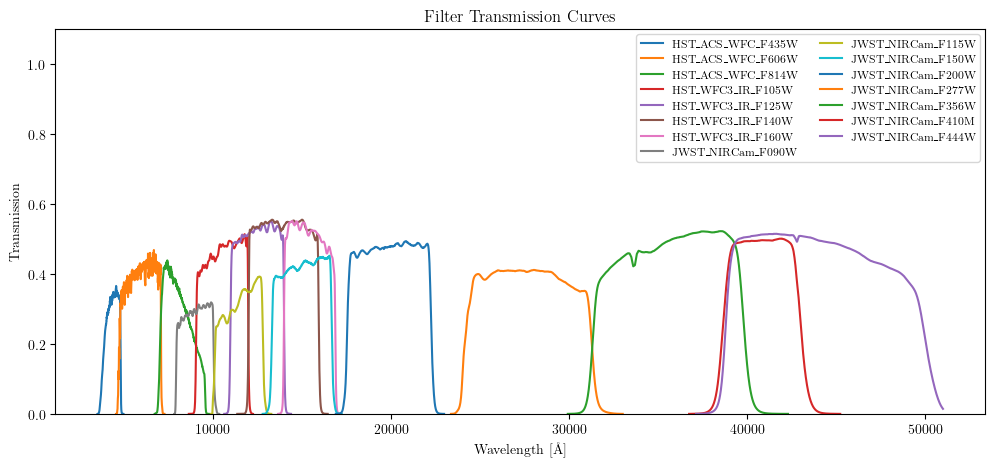

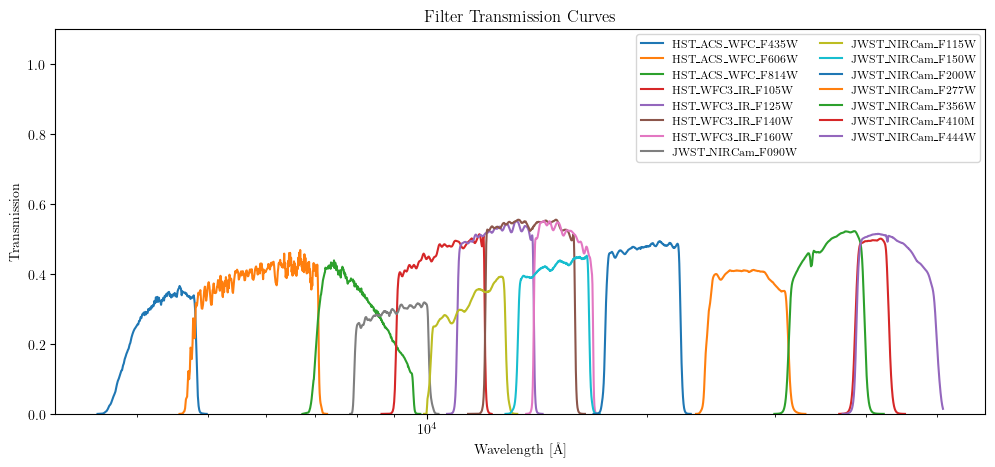

In [20]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

for ffile in filter_files:
    filt_data = np.loadtxt(ffile)
    wave = filt_data[:,0]          # wavelength in Å
    transmission = filt_data[:,1]  # 0-1 transmission
    filt_label = os.path.splitext(os.path.basename(ffile))[0]
    plt.plot(wave, transmission, label=filt_label)

plt.xlabel("Wavelength [Å]")
plt.ylabel("Transmission")
plt.title("Filter Transmission Curves")
plt.legend(fontsize=8, ncol=2)
plt.xscale('linear')
plt.ylim(0,1.1)
plt.show()

plt.figure(figsize=(12,5))

for ffile in filter_files:
    filt_data = np.loadtxt(ffile)
    wave = filt_data[:,0]          # wavelength in Å
    transmission = filt_data[:,1]  # 0-1 transmission
    filt_label = os.path.splitext(os.path.basename(ffile))[0]
    plt.plot(wave, transmission, label=filt_label)

plt.xscale('log')
plt.xlabel("Wavelength [Å]")
plt.ylabel("Transmission")
plt.title("Filter Transmission Curves")
plt.legend(fontsize=8, ncol=2)
plt.ylim(0,1.1)
plt.show()

## Photometry for all ages

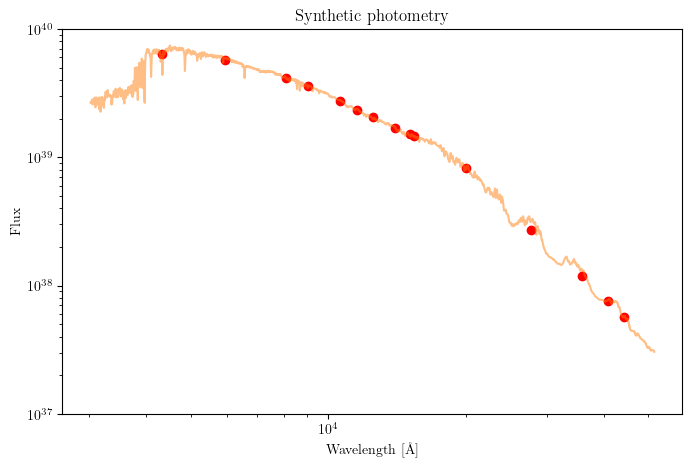

In [21]:

for t in years:

    burst = {
        "age": t,
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }
    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
       spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

    )

    # synthetic photometry
    photometry = model.photometry  # shape = (num_filters, )

    filter_wavelengths = []

for ffile in filter_files:
    filt_data = np.loadtxt(ffile)
    wave = filt_data[:,0]
    transmission = filt_data[:,1]
    eff_wave = np.sum(wave * transmission) / np.sum(transmission)
    filter_wavelengths.append(eff_wave)

filter_wavelengths = np.array(filter_wavelengths)
photometry = np.array(model.photometry)  # flux in each filter

plt.figure(figsize=(8,5))
plt.scatter(filter_wavelengths, photometry, color='red')
plt.plot(model.spec_wavs, model.spectrum, alpha=0.5)  # overlay SED
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux")
plt.title("Synthetic photometry")
plt.ylim(1e37,1e40)
plt.show()

    

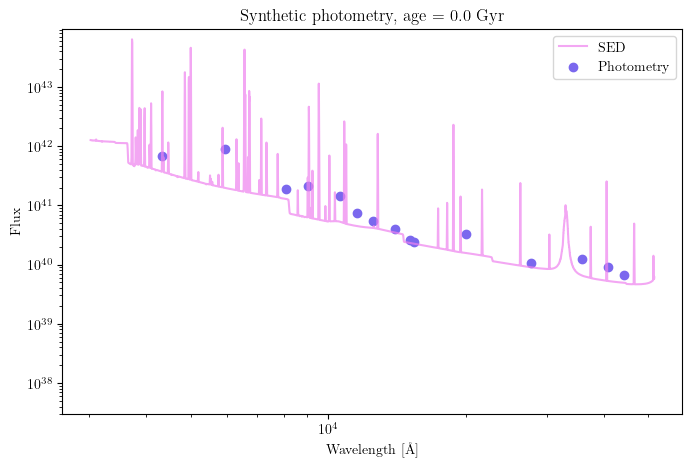

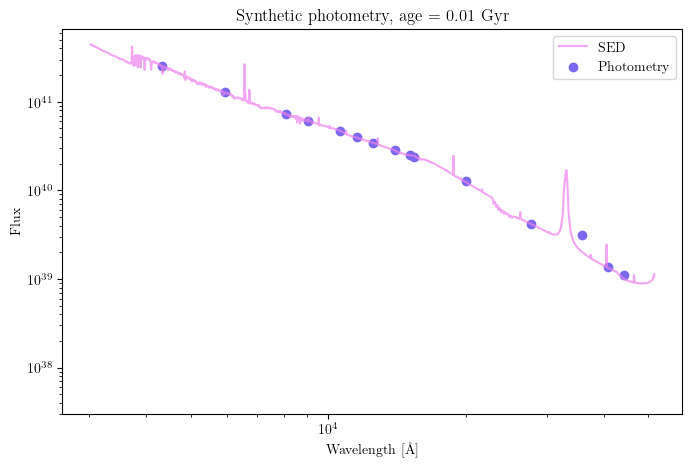

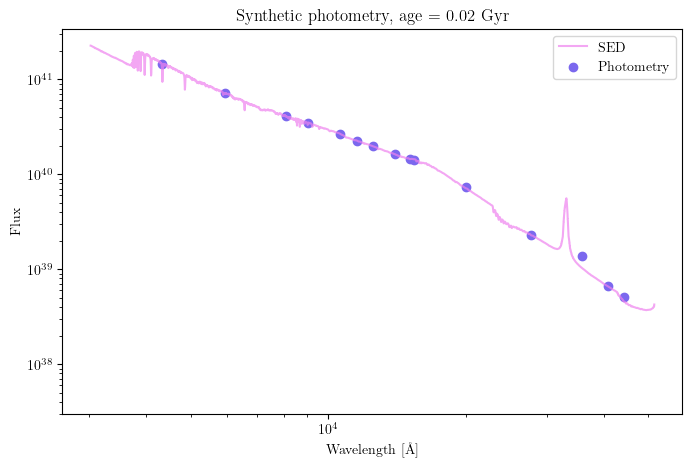

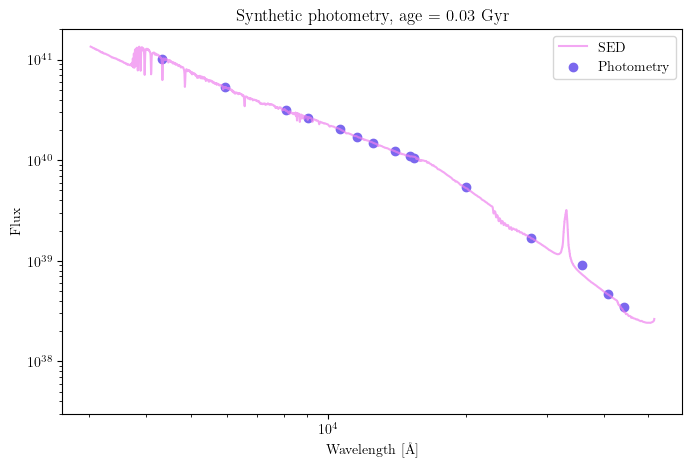

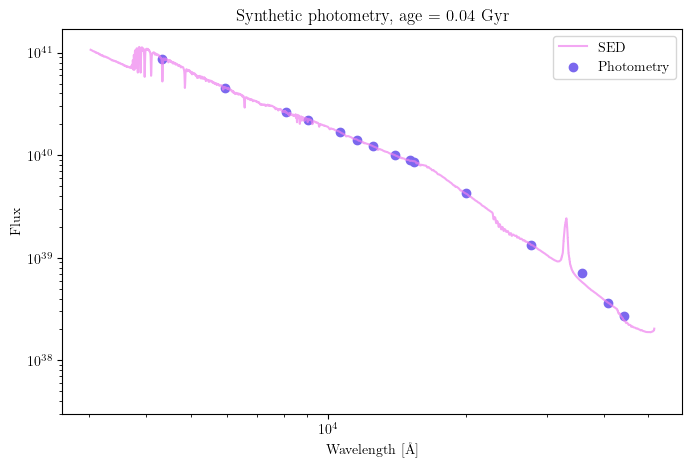

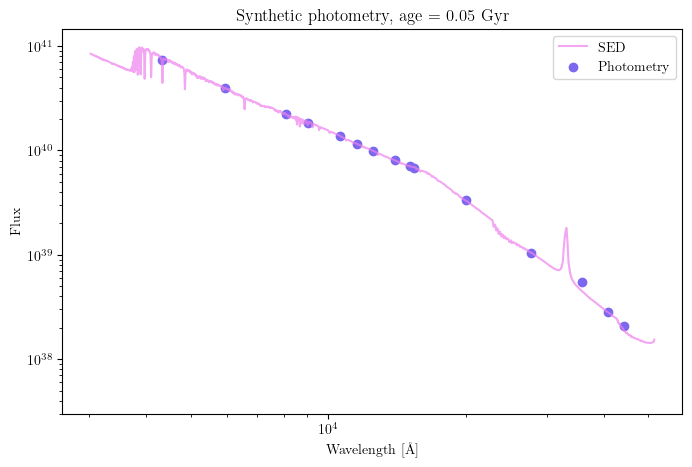

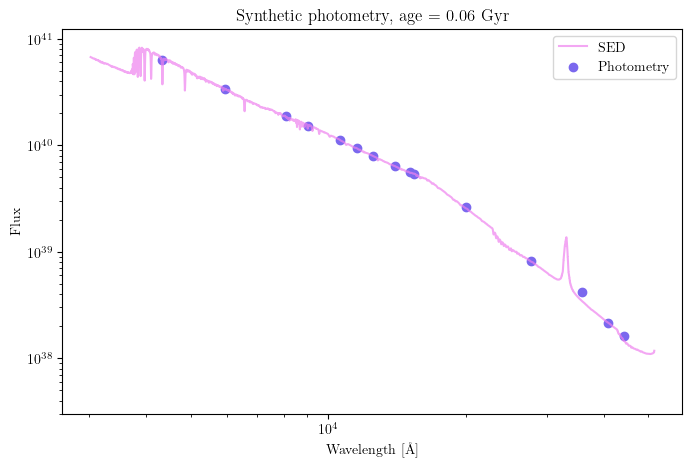

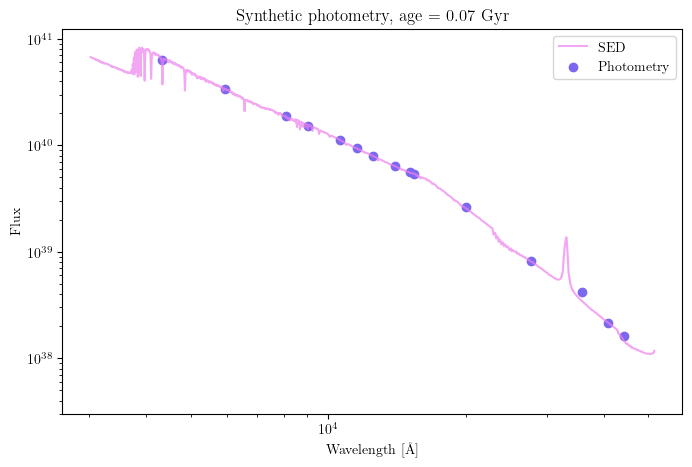

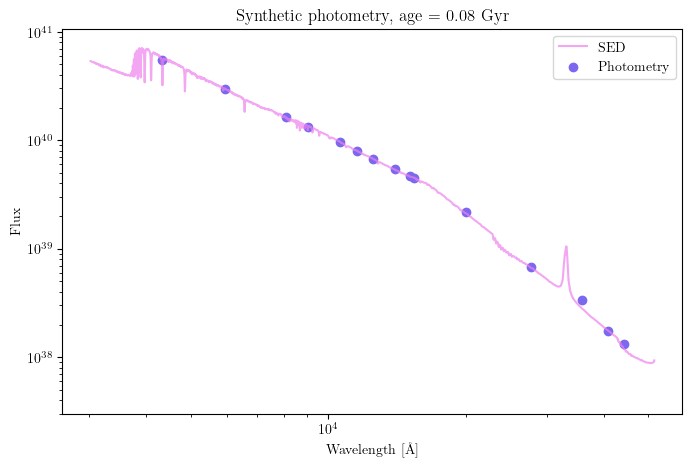

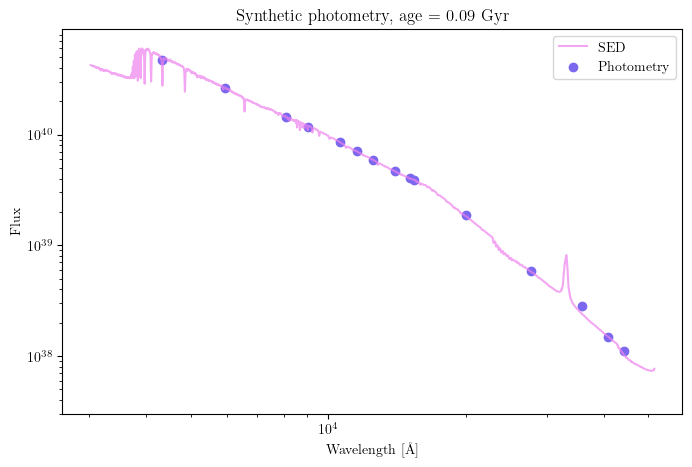

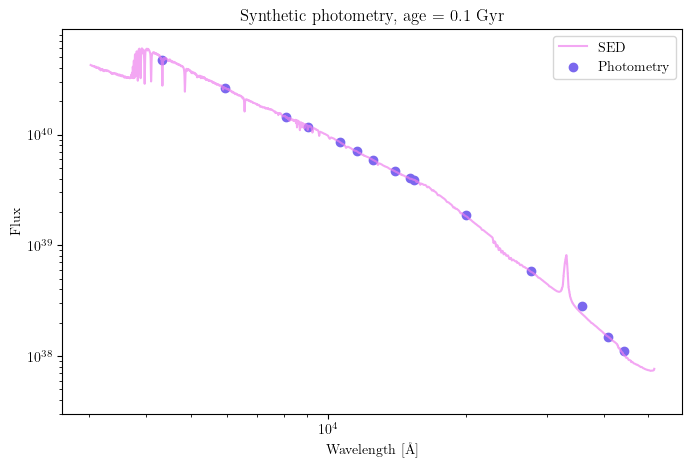

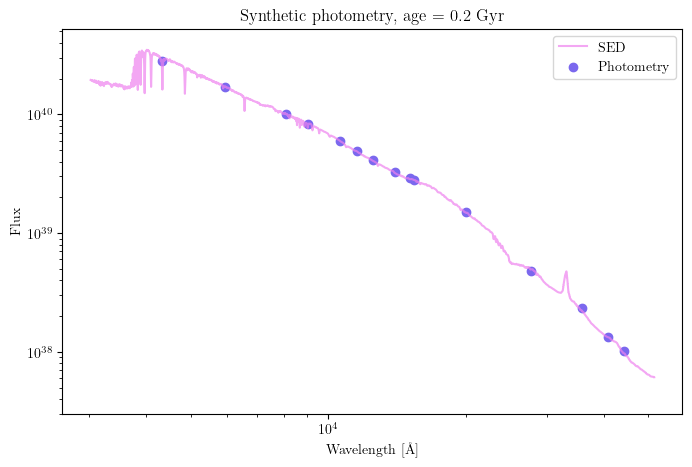

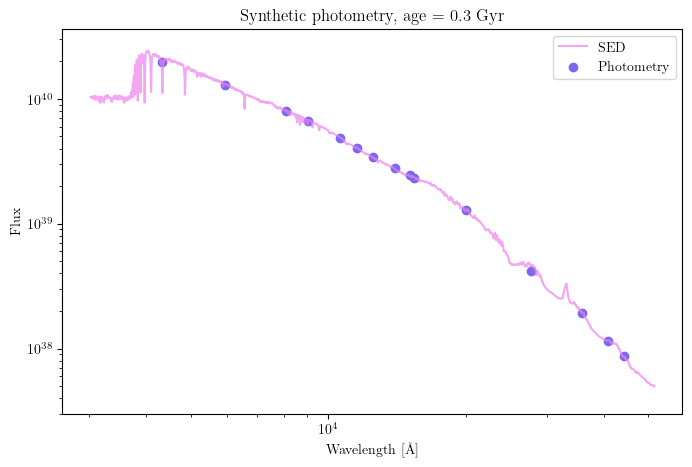

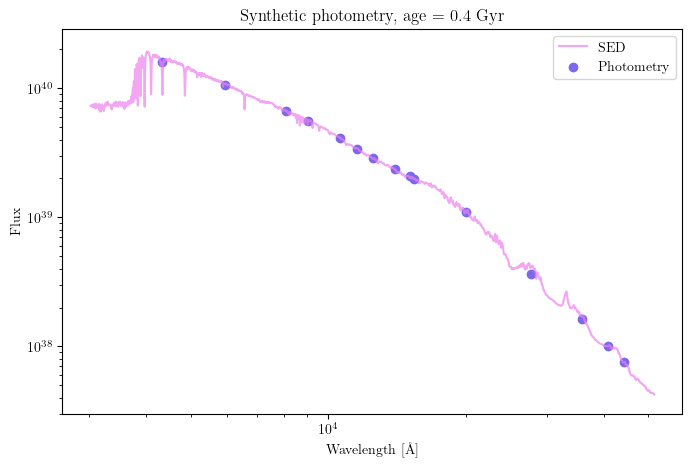

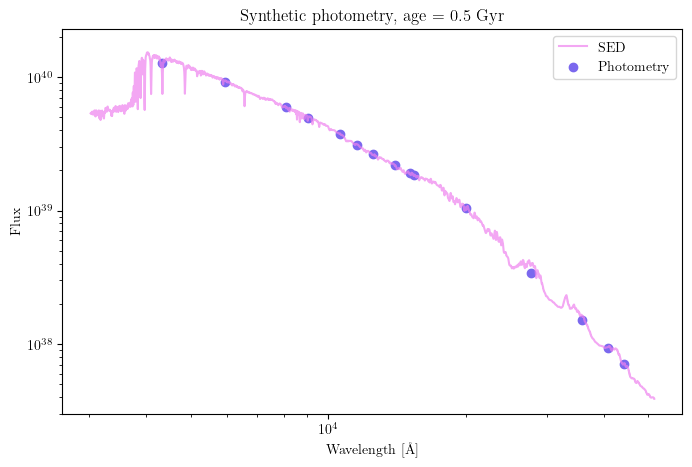

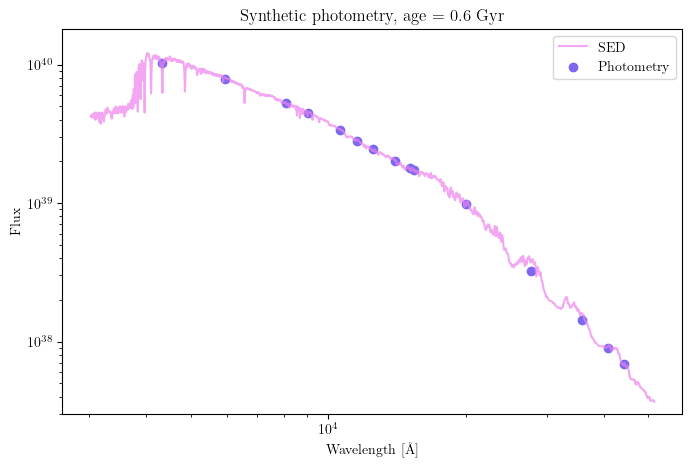

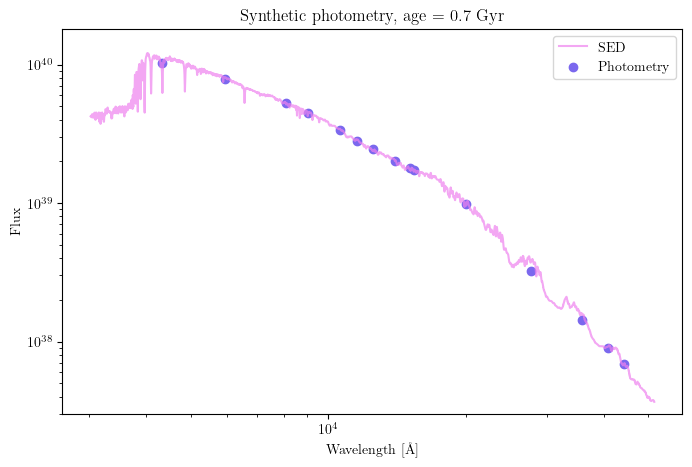

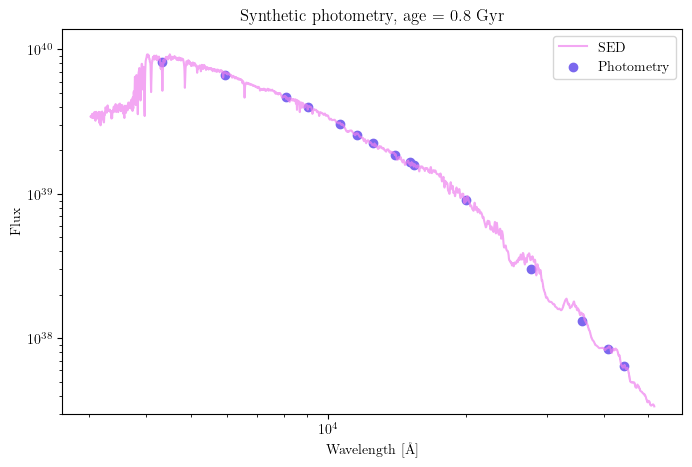

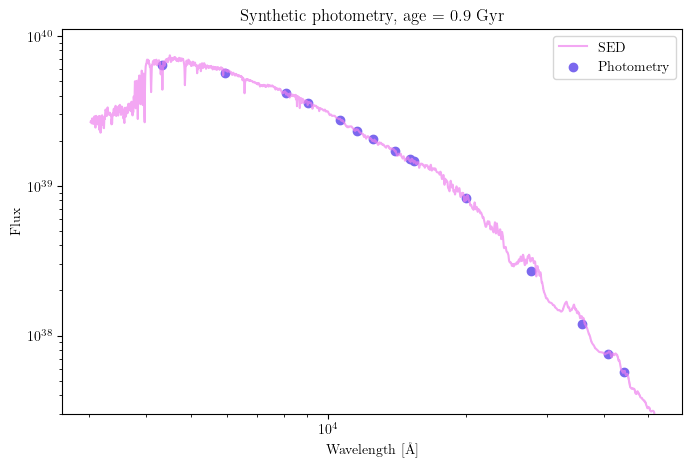

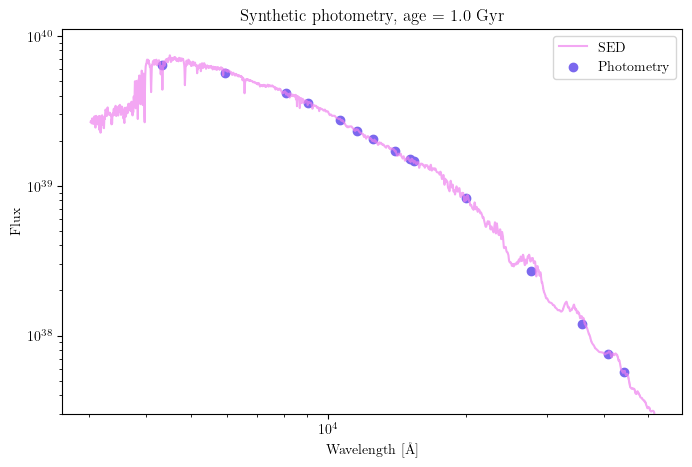

In [22]:
import matplotlib.pyplot as plt
import numpy as np

for t in years:

    # Build model components
    burst = {"age": t, "massformed": 10, "metallicity": 0.5}
    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs=np.arange(global_min - 500, global_max + 500, 5.)
    )

    # Compute effective filter wavelengths
    filter_wavelengths = []
    for ffile in filter_files:
        filt_data = np.loadtxt(ffile)
        wave = filt_data[:,0]
        transmission = filt_data[:,1]
        eff_wave = np.sum(wave * transmission) / np.sum(transmission)
        filter_wavelengths.append(eff_wave)
    filter_wavelengths = np.array(filter_wavelengths)

    # Plot
    y = model.spectrum  # flux in each filter
    plt.figure(figsize=(8,5))
    plt.plot(model.spec_wavs, y[:,1], label='SED', color='violet', alpha=0.7)
    plt.scatter(filter_wavelengths, model.photometry, color='mediumslateblue', label='Photometry')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Wavelength [Å]")
    plt.ylabel("Flux")
    plt.title(f"Synthetic photometry, age = {t} Gyr")
    plt.ylim(3e37,y.max()*1.5)
    plt.legend()
    plt.show()

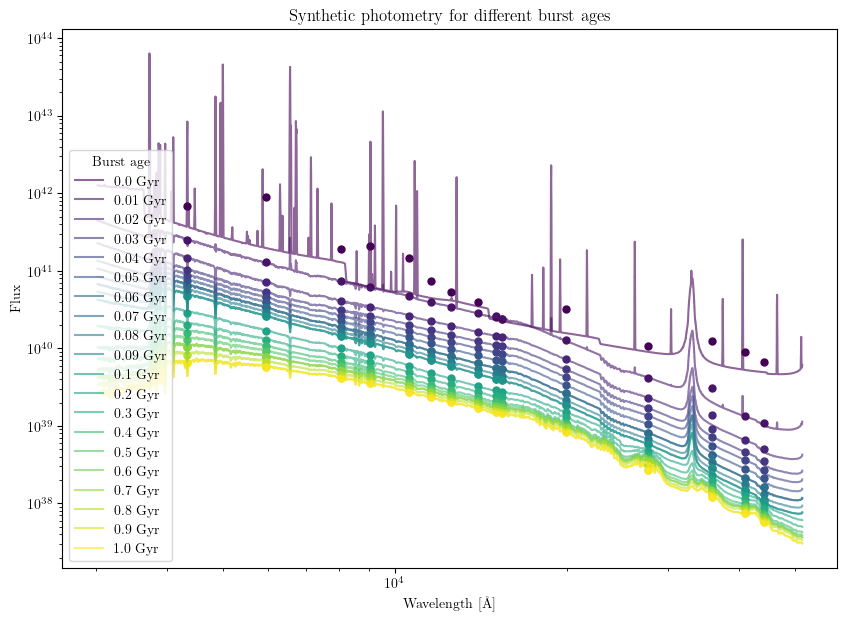

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Create one big figure
plt.figure(figsize=(10,7))

# Colour map for different ages
colors = cm.viridis(np.linspace(0, 1, len(years)))

# Precompute filter effective wavelengths ONCE (not inside loop)
filter_wavelengths = []
for ffile in filter_files:
    filt_data = np.loadtxt(ffile)
    wave = filt_data[:,0]
    transmission = filt_data[:,1]
    eff_wave = np.sum(wave * transmission) / np.sum(transmission)
    filter_wavelengths.append(eff_wave)
filter_wavelengths = np.array(filter_wavelengths)

for i, t in enumerate(years):

    burst = {"age": t, "massformed": 10, "metallicity": 0.5}
    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs=np.arange(global_min - 500, global_max + 500, 5.)
    )

    spectrum = model.spectrum[:,1]

    # Plot SED
    plt.plot(
        model.spec_wavs,
        spectrum,
        color=colors[i],
        alpha=0.6,
        label=f"{t} Gyr"
    )

    # Plot photometry
    plt.scatter(
        filter_wavelengths,
        model.photometry,
        color=colors[i],
        s=25
    )

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux")
plt.title("Synthetic photometry for different burst ages")

plt.legend(title="Burst age")
plt.show()

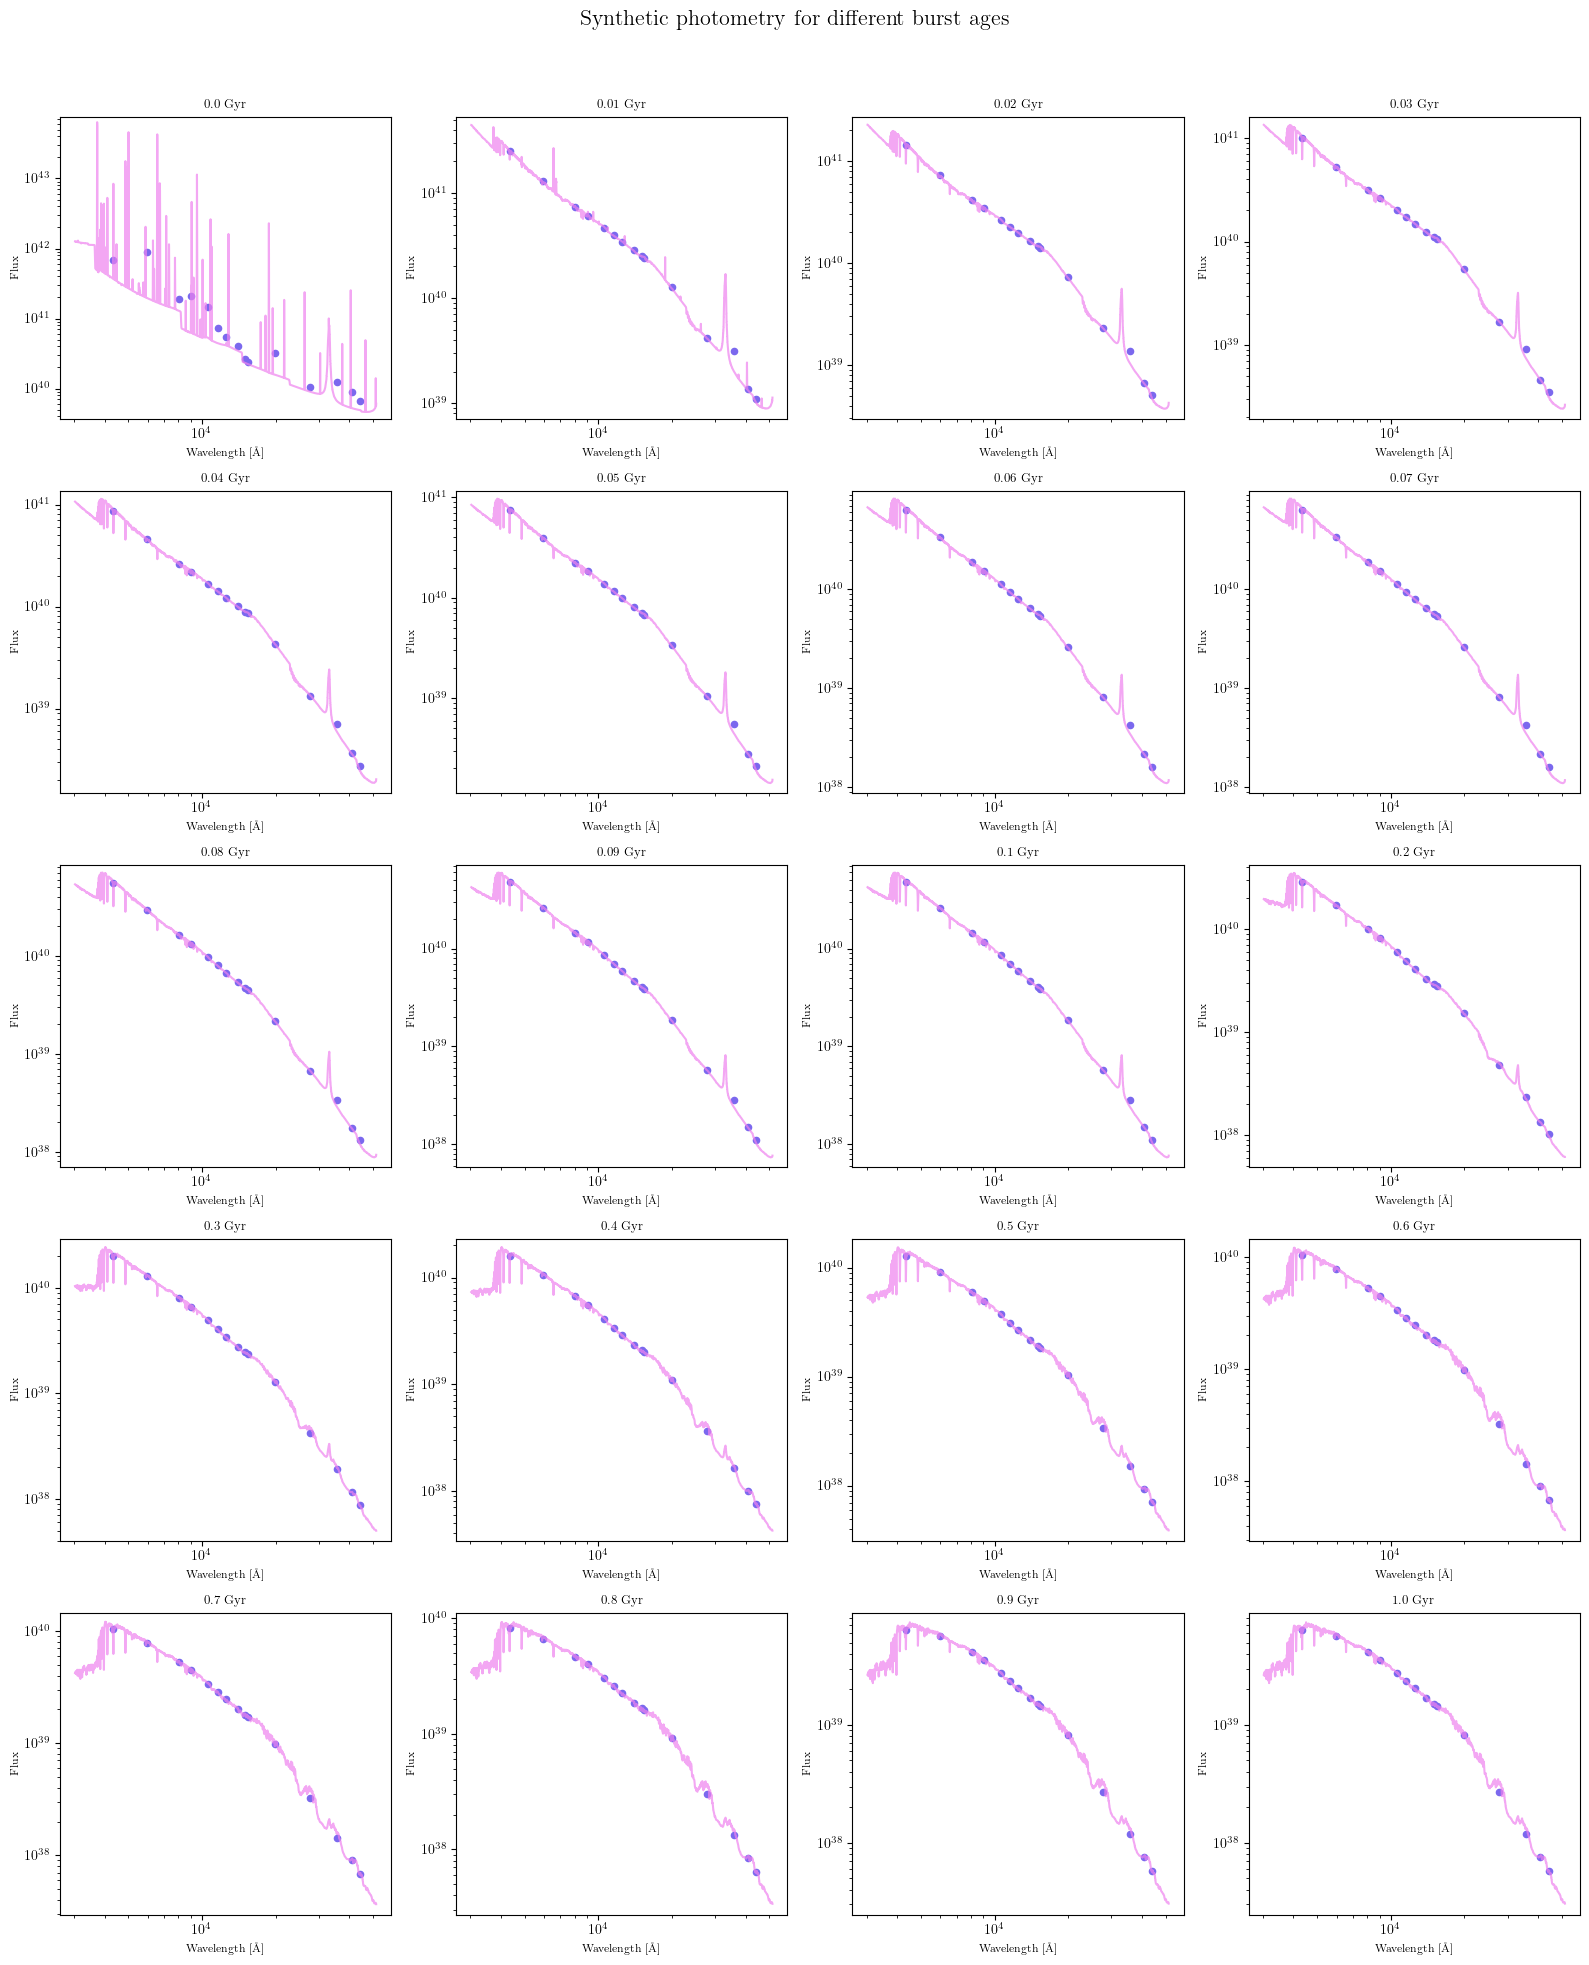

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Precompute filter effective wavelengths ONCE
filter_wavelengths = []
for ffile in filter_files:
    filt_data = np.loadtxt(ffile)
    wave = filt_data[:, 0]
    transmission = filt_data[:, 1]
    eff_wave = np.sum(wave * transmission) / np.sum(transmission)
    filter_wavelengths.append(eff_wave)
filter_wavelengths = np.array(filter_wavelengths)

# Grid size
n = len(years)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for i, t in enumerate(years):

    burst = {"age": t, "massformed": 10, "metallicity": 0.5}
    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs=np.arange(global_min - 500, global_max + 500, 5.)
    )

    ax = axes[i]

    spectrum = model.spectrum[:, 1]

    ax.plot(model.spec_wavs, spectrum, color='violet', alpha=0.7)
    ax.scatter(filter_wavelengths, model.photometry,
               color='mediumslateblue', s=20)

    ax.set_xscale('log')
    ax.set_yscale('log')

    # Auto-scale per panel
    ymin = spectrum[spectrum > 0].min()
    ymax = spectrum.max()
    ax.set_ylim(ymin*0.8, ymax*1.2)

    ax.set_title(f"{t} Gyr", fontsize=9)
    ax.set_xlabel("Wavelength [Å]", fontsize=8)
    ax.set_ylabel("Flux", fontsize=8)

# Turn off unused axes
for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("Synthetic photometry for different burst ages", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Photometry over time

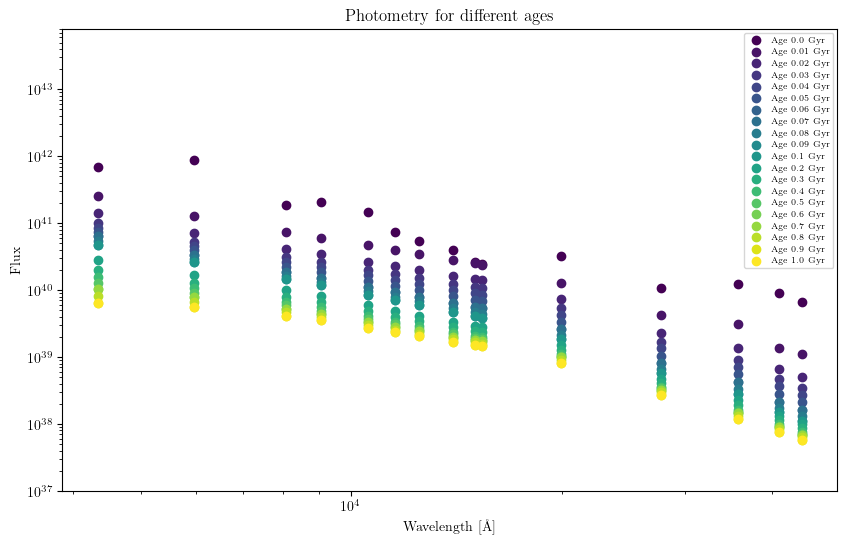

In [25]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

colors = cm.viridis(np.linspace(0,1,len(years)))

plt.figure(figsize=(10,6))

for i, t in enumerate(years):
    burst = {"age": t, "massformed": 10, "metallicity": 0.5}
    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs=np.arange(global_min - 500, global_max + 500, 5.)
    )

    filter_wavelengths = []
    for ffile in filter_files:
        filt_data = np.loadtxt(ffile)
        wave = filt_data[:,0]
        transmission = filt_data[:,1]
        eff_wave = np.sum(wave * transmission) / np.sum(transmission)
        filter_wavelengths.append(eff_wave)
    filter_wavelengths = np.array(filter_wavelengths)

    plt.scatter(filter_wavelengths, model.photometry, color=colors[i], label=f"Age {t} Gyr")

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux")
plt.title("Photometry for different ages")
plt.ylim(1e37,8e43)
plt.legend(fontsize=6, loc = "upper right")
plt.show()


### adding SNR

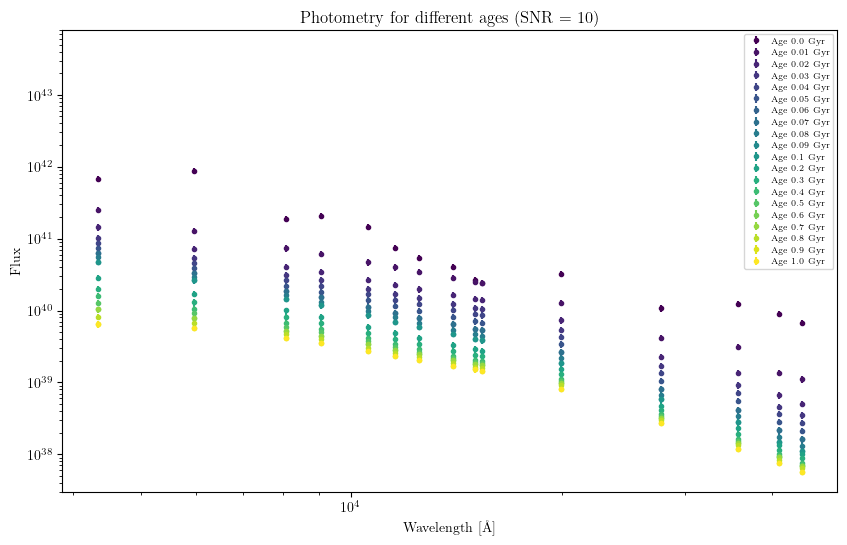

In [26]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

colors = cm.viridis(np.linspace(0, 1, len(years)))

# Precompute filter effective wavelengths ONCE
filter_wavelengths = []
for ffile in filter_files:
    filt_data = np.loadtxt(ffile)
    wave = filt_data[:,0]
    transmission = filt_data[:,1]
    eff_wave = np.sum(wave * transmission) / np.sum(transmission)
    filter_wavelengths.append(eff_wave)
filter_wavelengths = np.array(filter_wavelengths)

plt.figure(figsize=(10,6))

for i, t in enumerate(years):

    burst = {"age": t, "massformed": 10, "metallicity": 0.5}
    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs=np.arange(global_min - 500, global_max + 500, 5.)
    )

    flux = model.photometry

    # SNR = 10 → sigma = flux / 10
    sigma = flux / 10.

    plt.errorbar(
        filter_wavelengths,
        flux,
        yerr=sigma,
        fmt='.',
        color=colors[i],
        capsize=0,
        label=f"Age {t} Gyr"
    )

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux")
plt.title("Photometry for different ages (SNR = 10)")
plt.ylim(3e37, 8e43)
plt.legend(fontsize=6, loc="upper right")
plt.show()